# Simon's Algorithm

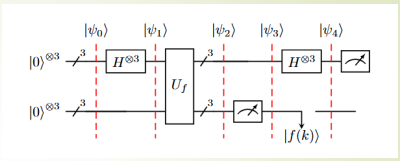

In [1]:
from qiskit import *
from qiskit_aer import *
from qiskit.visualization import *
from qiskit.quantum_info import *

import numpy as np

## Visualizatin function

In [2]:
def qplot(x):
    return x.draw(scale=0.8, fold=-1, cregbundle=False, initial_state=True)

## Simon's Algorithm Oracle

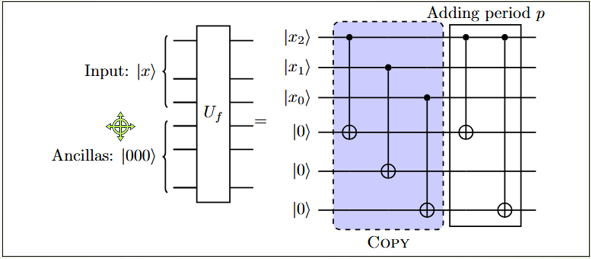

In [39]:
p = '110'

In [40]:
# Number of qubits
n = len(p)

# create the quantum registers 
qm = QuantumRegister(n, name = 'qubits')
qa = QuantumRegister(n, name = 'ancilla')

# create the classical register with 2n bits
cbits1 = ClassicalRegister(n, name = 'cbits1' )
cbits2 = ClassicalRegister(n, name = 'cbits2' )


In [41]:
# create the quantum Circuit
qc = QuantumCircuit(qm, qa, cbits2)

# 1st step: Applying Hadamard gates to main register
qc.h(qm)
qc.barrier(label = '1st')

# 2nd step: Applying Oracle
## First part: Copy block
qc.mcx([qm], qa)
qc.barrier(label = 'COPY')

for i in range(n):
    if p[i] == '1':
        qc.cx(1, i+n)
qc.barrier(label = 'Oracle')

# 3rd step: Measuring the Ancillary qubits
#qc.measure(qa, cbits1)
#qc.barrier()

# 4th step: Applying Hadamard to main qubits
qc.h(qm)

# 5th step: Measuring the main qubits
qc.measure(qm, cbits2)



qplot(qc)

┌───┐ 1st                                     COPY                      Oracle ┌───┐┌─┐                  
 qubits_0: |0>┤ H ├──░────■──────────────────────────────────░──────────────────────────░────┤ H ├┤M├──────────────────
              ├───┤  ░    │                                  ░                          ░    ├───┤└╥┘┌─┐               
 qubits_1: |0>┤ H ├──░────┼────■─────────────────────────────░─────■────■────■────■─────░────┤ H ├─╫─┤M├───────────────
              ├───┤  ░    │    │                             ░     │    │    │    │     ░    ├───┤ ║ └╥┘┌─┐            
 qubits_2: |0>┤ H ├──░────┼────┼────■────────────────────────░─────┼────┼────┼────┼─────░────┤ H ├─╫──╫─┤M├────────────
              ├───┤  ░    │    │    │                        ░     │    │    │    │     ░    ├───┤ ║  ║ └╥┘┌─┐         
 qubits_3: |0>┤ H ├──░────┼────┼────┼────■───────────────────░─────┼────┼────┼────┼─────░────┤ H ├─╫──╫──╫─┤M├─────────
              ├───┤  ░    │    │    │    │                   ░     │    │    │    │     ░    ├───┤ ║  ║  ║ └╥┘┌─┐      
 qubits_4: |0>┤ H ├──░────┼────┼────┼────┼────■──────────────░─────┼────┼────┼────┼─────░────┤ H ├─╫──╫──╫──╫─┤M├──────
              ├───┤  ░    │    │    │    │    │              ░     │    │    │    │     ░    ├───┤ ║  ║  ║  ║ └╥┘┌─┐   
 qubits_5: |0>┤ H ├──░────┼────┼────┼────┼────┼────■─────────░─────┼────┼────┼────┼─────░────┤ H ├─╫──╫──╫──╫──╫─┤M├───
              ├───┤  ░    │    │    │    │    │    │         ░     │    │    │    │     ░    ├───┤ ║  ║  ║  ║  ║ └╥┘┌─┐
 qubits_6: |0>┤ H ├──░────┼────┼────┼────┼────┼────┼────■────░─────┼────┼────┼────┼─────░────┤ H ├─╫──╫──╫──╫──╫──╫─┤M├
              └───┘  ░  ┌─┴─┐  │    │    │    │    │    │    ░   ┌─┴─┐  │    │    │     ░    └───┘ ║  ║  ║  ║  ║  ║ └╥┘
ancilla_0: |0>───────░──┤ X ├──┼────┼────┼────┼────┼────┼────░───┤ X ├──┼────┼────┼─────░──────────╫──╫──╫──╫──╫──╫──╫─
                     ░  └───┘┌─┴─┐  │    │    │    │    │    ░   └───┘  │    │    │     ░          ║  ║  ║  ║  ║  ║  ║ 
ancilla_1: |0>───────░───────┤ X ├──┼────┼────┼────┼────┼────░──────────┼────┼────┼─────░──────────╫──╫──╫──╫──╫──╫──╫─
                     ░       └───┘┌─┴─┐  │    │    │    │    ░        ┌─┴─┐  │    │     ░          ║  ║  ║  ║  ║  ║  ║ 
ancilla_2: |0>───────░────────────┤ X ├──┼────┼────┼────┼────░────────┤ X ├──┼────┼─────░──────────╫──╫──╫──╫──╫──╫──╫─
                     ░            └───┘┌─┴─┐  │    │    │    ░        └───┘  │    │     ░          ║  ║  ║  ║  ║  ║  ║ 
ancilla_3: |0>───────░─────────────────┤ X ├──┼────┼────┼────░───────────────┼────┼─────░──────────╫──╫──╫──╫──╫──╫──╫─
                     ░                 └───┘┌─┴─┐  │    │    ░             ┌─┴─┐  │     ░          ║  ║  ║  ║  ║  ║  ║ 
ancilla_4: |0>───────░──────────────────────┤ X ├──┼────┼────░─────────────┤ X ├──┼─────░──────────╫──╫──╫──╫──╫──╫──╫─
                     ░                      └───┘┌─┴─┐  │    ░             └───┘┌─┴─┐   ░          ║  ║  ║  ║  ║  ║  ║ 
ancilla_5: |0>───────░───────────────────────────┤ X ├──┼────░──────────────────┤ X ├───░──────────╫──╫──╫──╫──╫──╫──╫─
                     ░                           └───┘┌─┴─┐  ░                  └───┘   ░          ║  ║  ║  ║  ║  ║  ║ 
ancilla_6: |0>───────░────────────────────────────────┤ X ├──░──────────────────────────░──────────╫──╫──╫──╫──╫──╫──╫─
                     ░                                └───┘  ░                          ░          ║  ║  ║  ║  ║  ║  ║ 
  cbits2_0: 0 ═════════════════════════════════════════════════════════════════════════════════════╩══╬══╬══╬══╬══╬══╬═
                                                                                                      ║  ║  ║  ║  ║  ║ 
  cbits2_1: 0 ════════════════════════════════════════════════════════════════════════════════════════╩══╬══╬══╬══╬══╬═
                                                                                                         ║  ║  ║  ║  ║ 
  cbits2_2: 0 ════════════════════════════════════════

In [42]:
backend = QasmSimulator()
transpiled_qc = transpile(qc, backend)
job = backend.run(transpiled_qc)
result = job.result()
counts = result.get_counts()
counts

{'1001010': 5,
 '1110100': 18,
 '0100111': 12,
 '1100001': 11,
 '0011101': 9,
 '1111111': 7,
 '1000011': 10,
 '1000101': 15,
 '0000011': 4,
 '0110100': 6,
 '0101100': 8,
 '1001110': 2,
 '1110000': 11,
 '0111101': 7,
 '0100011': 9,
 '1100110': 8,
 '0011100': 14,
 '1000000': 5,
 '1111110': 7,
 '0101111': 6,
 '0110001': 9,
 '1110111': 6,
 '1001011': 8,
 '0001101': 11,
 '0010100': 7,
 '1101001': 7,
 '1111011': 6,
 '1000111': 4,
 '0000001': 9,
 '1111010': 6,
 '1000100': 8,
 '0000010': 12,
 '0100110': 9,
 '0111010': 7,
 '0001111': 9,
 '1110101': 9,
 '0001011': 13,
 '0100010': 13,
 '0111110': 9,
 '0000000': 14,
 '1000110': 11,
 '1111100': 8,
 '1110010': 5,
 '0001010': 5,
 '0100001': 7,
 '0111111': 4,
 '1011011': 8,
 '0111011': 7,
 '0100101': 7,
 '0001110': 7,
 '1011010': 4,
 '0001001': 16,
 '1011101': 5,
 '1101110': 4,
 '0010000': 4,
 '1100111': 7,
 '0010010': 6,
 '1010001': 7,
 '1101011': 6,
 '1011001': 8,
 '1100100': 15,
 '0011010': 11,
 '0000111': 7,
 '1010110': 8,
 '1100010': 15,
 '001111

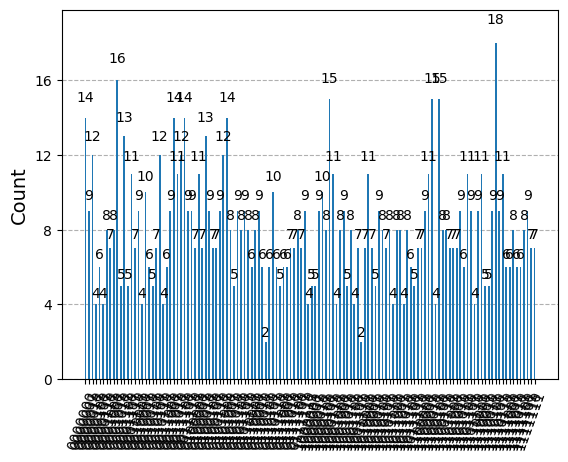

In [43]:
plot_histogram(counts)